In [1]:
import os
import chromadb
import warnings
warnings.filterwarnings("ignore")
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools import TavilySearchResults
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain import hub
from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, MessagesState, START
from langchain_core.tools import tool
from typing import Literal
from langchain_community.document_loaders import WebBaseLoader, TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import Graph
from langchain.vectorstores import Chroma
from pydantic import BaseModel, Field
from IPython.display import Image, display
from typing import List
from typing_extensions import TypedDict
from langchain.schema import Document
from langchain.tools.retriever import create_retriever_tool
from langgraph.prebuilt import tools_condition
from langchain_core.prompts import PromptTemplate
from langgraph.types import Command


USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
load_dotenv()
embeddings = OpenAIEmbeddings()
parser = StrOutputParser()
llm = ChatOpenAI(model="gpt-4o-mini")

def displayGraph(app):
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        # This requires some extra dependencies and is optional
        print(e)

In [3]:
@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    return

In [4]:
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    return 

In [5]:
tools = [transfer_to_multiplication_expert, transfer_to_addition_expert]

In [6]:
llm_with_tools = llm.bind_tools(tools)

In [7]:
ai_message=llm_with_tools.invoke("what's (3 + 5) * 12. Provide me the output")
ai_message

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_FjFmhU1YDM9oUS0k5JOOrHOZ', 'function': {'arguments': '{}', 'name': 'transfer_to_addition_expert'}, 'type': 'function'}, {'id': 'call_uaV39uPM4l8oURcNbtHuhLv0', 'function': {'arguments': '{}', 'name': 'transfer_to_multiplication_expert'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 76, 'total_tokens': 125, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BRnd6PTthOOUZreCR0jx4CVsIpYEg', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-83ff566c-9524-4845-a837-2dc85c8b638b-0', tool_calls=[{'name': 'transfer_to_addition_expert', 'args': {}, 'id': 'call_FjFmhU1YDM9oUS0k5JOOrHOZ', 'type': 'tool_ca

In [8]:
def additional_expert(state:MessagesState)-> Command[Literal["multiplication_expert", "__end__"]]:
    
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    
    ai_msg = llm.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
    
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        
        return Command(
            goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]}
        )
    return {"messages": [ai_msg]}

In [9]:
def multiplication_expert(state:MessagesState)-> Command[Literal["additional_expert", "__end__"]]:
    
    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = llm.bind_tools([transfer_to_addition_expert]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

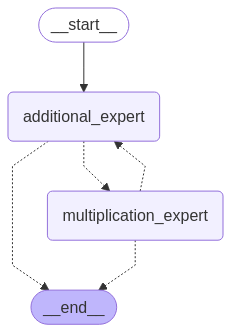

In [10]:
graph=StateGraph(MessagesState)

graph.add_node("additional_expert",additional_expert)
graph.add_node("multiplication_expert",multiplication_expert)

graph.add_edge(START, "additional_expert")
app=graph.compile()
displayGraph(app)

In [11]:
app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_9DPkgJE3z91YTKW7FZVP7IWc", 'type': 'invalid_request_error', 'param': 'messages', 'code': None}}

In [13]:
from langchain_core.messages import convert_to_messages
def pretty_print_messages(update):
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")

    for node_name, node_update in update.items():
        print(f"Update from node {node_name}:")
        print("\n")

        for m in convert_to_messages(node_update["messages"]):
            m.pretty_print()
        print("\n")

In [14]:
for chunk in app.stream(
    {"messages": [("user", "what's (3 + 5) * 12. Provide me the output")]},
):
    print("****chunk...****")
    
    pretty_print_messages(chunk)

****chunk...****
Update from node additional_expert:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_multiplication_expert (call_gUAPZkXHyp4JDezwaKY500uu)
 Call ID: call_gUAPZkXHyp4JDezwaKY500uu
  Args:
================================= Tool Message =================================

Successfully transferred


****chunk...****
Update from node multiplication_expert:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_addition_expert (call_vDXHBhNBvqF1DQy8JzcbnpC3)
 Call ID: call_vDXHBhNBvqF1DQy8JzcbnpC3
  Args:
================================= Tool Message =================================

Successfully transferred


****chunk...****
Update from node additional_expert:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_multiplication_expert (call_PSxjw1AXNyvPR8Dt6DVg5z8s)
 Call ID: call_PSxjw1AXNyvPR8Dt6DVg5z8s


BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_PSxjw1AXNyvPR8Dt6DVg5z8s", 'type': 'invalid_request_error', 'param': 'messages', 'code': None}}